Importing Required Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
train_data = pd.read_csv('/content/train.csv')


In [17]:
# Data Inspection
print(train_data.info())
print(train_data.head())
print(train_data.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

In [18]:
# Check Missing Values
missing_values = train_data.isnull().sum()
print("\nMissing Values:")
print(missing_values)


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [19]:
# Handle Missing Data
train_data["Age"].fillna(train_data["Age"].median(), inplace=True)
train_data["Embarked"].fillna(train_data["Embarked"].mode()[0], inplace=True)

print(train_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


<ipython-input-19-328081545b45>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["Age"].fillna(train_data["Age"].median(), inplace=True)
<ipython-input-19-328081545b45>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [34]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Distribution of Continuous Variables

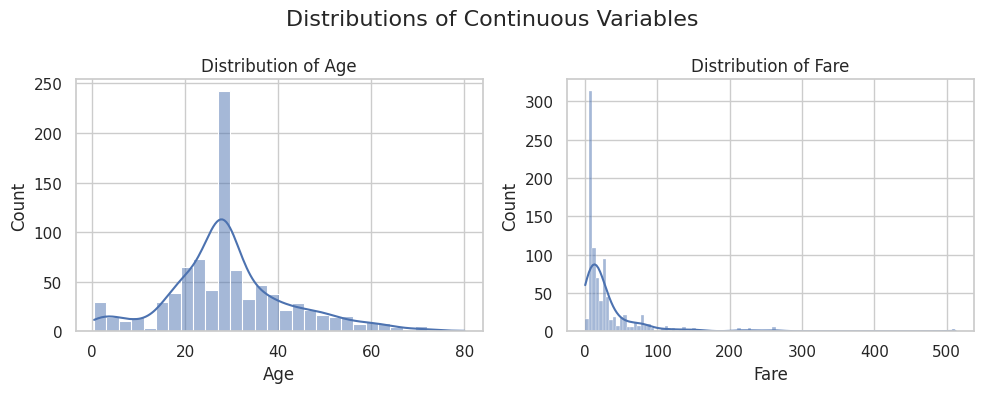

In [20]:
# Function to plot histograms and observe distributions
def plot_distributions(data, features, title):
    fig, axes = plt.subplots(1, len(features), figsize=(5 * len(features), 4))
    for ax, feature in zip(axes, features):
        sns.histplot(data[feature], kde=True, ax=ax)
        ax.set_title(f'Distribution of {feature}')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Call the function for 'Age' and 'Fare'
plot_distributions(train_data, ['Age', 'Fare'], "Distributions of Continuous Variables")


Survival by Passenger Class and Gender

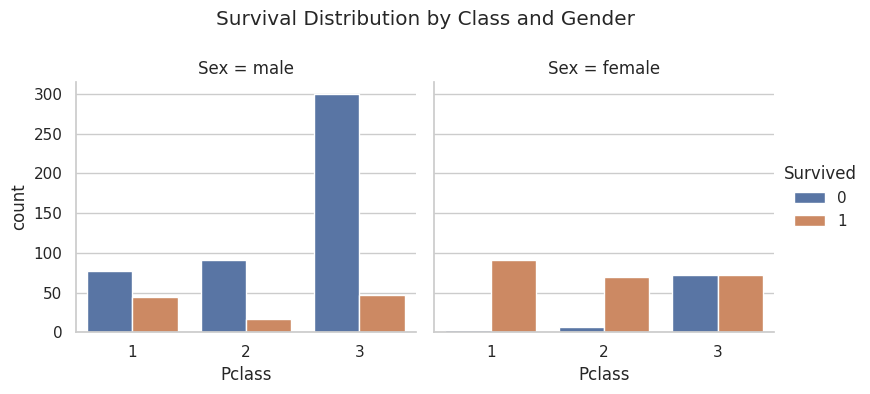

In [25]:
# Survival by Pclass and Sex
sns.catplot(x="Pclass", hue="Survived", col="Sex", data=train_data, kind="count", height=4, aspect=1)
plt.subplots_adjust(top=0.8)
plt.suptitle("Survival Distribution by Class and Gender")
plt.show()


Correlation Heatmap

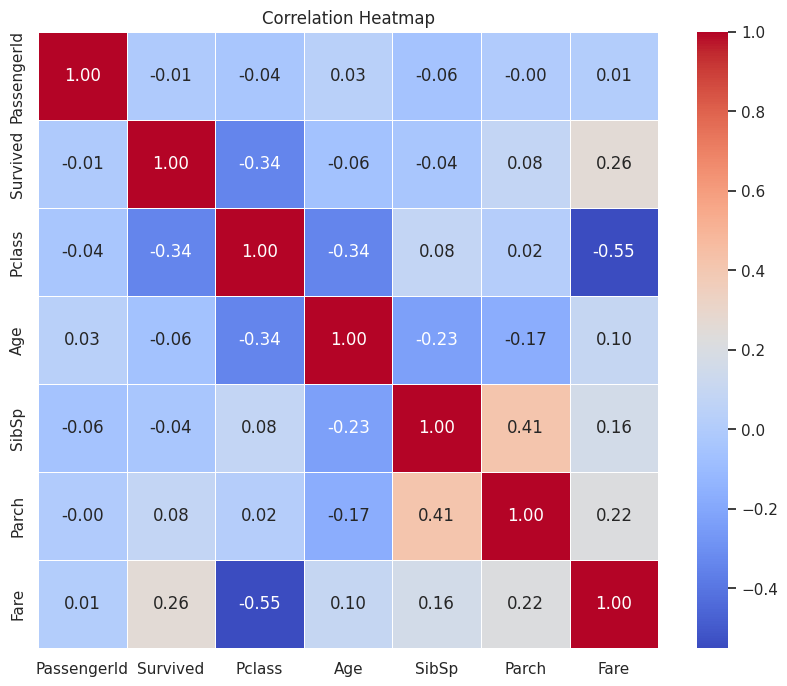

In [26]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = train_data.corr(numeric_only=True)  # Update for future pandas versions if needed
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


Fare Distribution by Survival

<ipython-input-27-6570a99e775c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=train_data, palette="Set2")


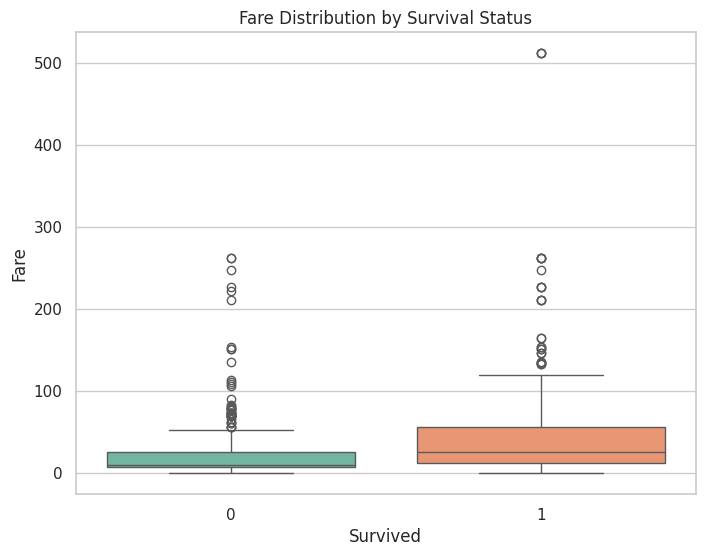

In [27]:
# Boxplot for Fare distribution by Survival status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=train_data, palette="Set2")
plt.title("Fare Distribution by Survival Status")
plt.show()


Summary of Value Counts for Categorical Data

In [29]:
# Value counts for Embarked
embarked_counts = train_data['Embarked'].value_counts()
print("Embarked Value Counts:\n", embarked_counts)



Embarked Value Counts:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [30]:
# Observations
print("\nEDA Observations:")
print("- Age: Peaks observed around 20–30 years, indicating a younger passenger demographic.")
print("- Fare: Skewed distribution; survivors generally paid higher fares.")
print("- Survival: Higher for females and first-class passengers.")
print("- Correlation: Pclass and Fare have a notable inverse correlation.")


EDA Observations:
- Age: Peaks observed around 20–30 years, indicating a younger passenger demographic.
- Fare: Skewed distribution; survivors generally paid higher fares.
- Survival: Higher for females and first-class passengers.
- Correlation: Pclass and Fare have a notable inverse correlation.
